# covid_main 終了時点の感度分析

## 1. 分析の目的

この notebook では、`covid_main` ダミーの終了時点を変えたときに、状態空間モデルの当てはまりと係数解釈がどのように変わるかを確認する。

ここで見たいのは、AIC/BIC だけではない。`covid_main` の期間設定を変えると、パンデミックの持続的影響、第一波の短期効果、後続統計接続補正である `post_stat_change` の分担が変わる可能性がある。そのため、次の観点を合わせて見る。

- 統計的な当てはまり: log likelihood, AIC, BIC
- 係数の安定性: `covid_main`, `covid_wave1`, `post_stat_change`
- `post_stat_change` が covid_main の終期設定に吸収されていないか
- トレンド成分に不自然な屈曲が出ていないか
- 残差に自己相関が残っていないか
- 終了時点として社会的に説明しやすいか

これは探索分析であり、ここで得た結果をそのまま論文に反映するものではない。

## 2. 比較する仕様

`covid_main` は、COVID-19 による持続的な市場構造変化を表すダミーとして扱う。ここでは開始時点を 2020-03-01 に固定し、終了時点だけを変える。

| model_id | covid_main の期間 | 位置づけ |
| :--- | :--- | :--- |
| M1 | 2020-03-01 〜 2021-12-01 | 2021年末で持続的影響が一区切りしたと見る仕様 |
| M2 | 2020-03-01 〜 2022-03-01 | 2021年度末までを構造変化期間と見る仕様 |
| M2b | 2020-03-01 〜 2022-06-01 | 補助仕様。2022年前半までを含める |
| M3 | 2020-03-01 〜 2022-12-01 | 2022年末までを含める仕様 |
| M4 | 2020-03-01 〜 2023-05-01 | 5類移行時期までを含める仕様 |
| M5 | 2020-03-01 以降ずっと | covid_main を恒久的な水準変化として扱う仕様 |

他のダミー、モデル構造、目的変数はできるだけ主分析と揃える。つまり、ここで意図的に動かすのは `covid_main` の終了時点だけである。

In [1]:
# 3. 必要ライブラリの import とパス設定
# リポジトリルートから実行する想定。notebook を別の場所から開いても、親をたどって root を探す。

from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning


PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != "Transport_amount_project" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_connected_parcel_data
from src.features import get_default_model_config, prepare_event_data
from src.paths import OUTPUT_DIR, PROCESSED_DATA_DIR
from src.ssm_models import LocalLinearTrendSeasonalWithMultiFixedExog


DATA_PATH = PROCESSED_DATA_DIR / "parcel_volume_connected.csv"
SENSITIVITY_DIR = OUTPUT_DIR / "sensitivity"
SENSITIVITY_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Output path:", SENSITIVITY_DIR)

Project root: c:\Users\fugat\Desktop\python_project\Transport_amount_project
Data path: C:\Users\fugat\Desktop\python_project\Transport_amount_project\data\processed\parcel_volume_connected.csv
Output path: C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity


In [2]:
# 4. データ読み込み
# 後続統計接続済みのデータを使う。post_stat_change はこのデータ、または data_loader 側で補われる。

df_base = load_connected_parcel_data(str(DATA_PATH))
base_config = get_default_model_config(include_connection_dummy=True)

print(f"Period: {df_base.index.min().date()} to {df_base.index.max().date()}")
print(f"Rows: {len(df_base):,}")
display(df_base.head())
display(df_base.tail())

Period: 2002-04-01 to 2026-02-01
Rows: 287


,year,month,Transport_tonnage,number_parcels,post_stat_change,y
label,,,,,,
2002-04-01,2002,4,5933686.0,218721.0,0,12.295552
2002-05-01,2002,5,5474539.0,208283.0,0,12.246653
2002-06-01,2002,6,5430018.0,218633.0,0,12.295150
2002-07-01,2002,7,6345951.0,271764.0,0,12.512689
2002-08-01,2002,8,5354671.0,217650.0,0,12.290644


,year,month,Transport_tonnage,number_parcels,post_stat_change,y
label,,,,,,
2025-10-01,2025,10,204844.0,405217.0,1,12.912178
2025-11-01,2025,11,208550.0,409319.0,1,12.922250
2025-12-01,2025,12,224966.0,510426.0,1,13.143001
2026-01-01,2026,1,191865.0,380997.0,1,12.850547
2026-02-01,2026,2,203458.0,349832.0,1,12.765208


In [3]:
# 5. baseline となる特徴量の確認
# covid_main はこのあと上書きする。ここでは、固定して使う他のダミーが期待通り存在するかを見る。

df_check, _, _ = prepare_event_data(df_base.copy(), base_config)
fixed_dummies = ["hike_dummy", "covid_wave1", "covid_2021", "post_stat_change"]

dummy_summary = []
for name in fixed_dummies:
    active = df_check.index[df_check[name] == 1]
    dummy_summary.append(
        {
            "dummy": name,
            "exists": name in df_check.columns,
            "active_months": int(df_check[name].sum()),
            "first_active": active.min().date() if len(active) else None,
            "last_active": active.max().date() if len(active) else None,
        }
    )

dummy_summary_df = pd.DataFrame(dummy_summary)
display(dummy_summary_df)

,dummy,exists,active_months,first_active,last_active
0,hike_dummy,True,27,2017-10-01,2019-12-01
1,covid_wave1,True,2,2020-04-01,2020-05-01
2,covid_2021,True,9,2021-01-01,2021-09-01
3,post_stat_change,True,43,2022-08-01,2026-02-01


In [4]:
# 6. M1-M5/M2b の covid_main ダミーを作る
# ここでは仕様を DataFrame として明示し、各仕様で covid_main が何か月 active になるかを確認する。

covid_main_start = "2020-03-01"
specs = pd.DataFrame(
    [
        {"model_id": "M1", "covid_main_start": covid_main_start, "covid_main_end": "2021-12-01", "note": "2021年末まで"},
        {"model_id": "M2", "covid_main_start": covid_main_start, "covid_main_end": "2022-03-01", "note": "2021年度末まで"},
        {"model_id": "M2b", "covid_main_start": covid_main_start, "covid_main_end": "2022-06-01", "note": "補助仕様: 2022年前半まで"},
        {"model_id": "M3", "covid_main_start": covid_main_start, "covid_main_end": "2022-12-01", "note": "2022年末まで"},
        {"model_id": "M4", "covid_main_start": covid_main_start, "covid_main_end": "2023-05-01", "note": "5類移行時期まで"},
        {"model_id": "M5", "covid_main_start": covid_main_start, "covid_main_end": None, "note": "終了なし"},
    ]
)

active_months = []
for _, spec in specs.iterrows():
    config = dict(base_config)
    config["covid_main"] = (spec["covid_main_start"], spec["covid_main_end"])
    df_tmp, _, _ = prepare_event_data(df_base.copy(), config)
    active_months.append(int(df_tmp["covid_main"].sum()))

specs["covid_main_active_months"] = active_months
display(specs)

,model_id,covid_main_start,covid_main_end,note,covid_main_active_months
0,M1,2020-03-01,2021-12-01,2021年末まで,22
1,M2,2020-03-01,2022-03-01,2021年度末まで,25
2,M2b,2020-03-01,2022-06-01,補助仕様: 2022年前半まで,28
3,M3,2020-03-01,2022-12-01,2022年末まで,34
4,M4,2020-03-01,2023-05-01,5類移行時期まで,39
5,M5,2020-03-01,None,終了なし,72


In [5]:
# 7. 各仕様を順番に推定する
# 大きな関数にはせず、notebook 上で何をしているか見える形にする。
# ただし、パラメータ名と初期値だけはモデルごとに同じ作業なので、小さな補助関数にしている。

base_param_names = ["obs_error", "level_noise", "slope_noise", "seasonal_noise"]
start_hints = {"covid_main": -2.0, "covid_wave1": -2.0, "covid_2021": -3.0, "post_stat_change": 0.0}
param_name_overrides = {"hike_dummy": "hike_effect"}

def make_param_names(exog_names):
    return base_param_names + [param_name_overrides.get(name, f"{name}_effect") for name in exog_names]

def make_start_params(exog_names):
    return [0.01, 0.01, 0.001, 0.001] + [start_hints.get(name, 0.0) for name in exog_names]


comparison_rows = []
coefficient_rows = []
diagnostic_rows = []
trend_by_model = {}
residual_by_model = {}

for _, spec in specs.iterrows():
    model_id = spec["model_id"]
    print(f"Estimating {model_id} ...")

    config = dict(base_config)
    config["covid_main"] = (spec["covid_main_start"], spec["covid_main_end"])
    df_model, exog_data, exog_names = prepare_event_data(df_base.copy(), config)
    param_names = make_param_names(exog_names)

    row = {
        "model_id": model_id,
        "covid_main_start": spec["covid_main_start"],
        "covid_main_end": spec["covid_main_end"] if pd.notna(spec["covid_main_end"]) else "None",
        "status": "started",
        "error": "",
        "converged": None,
        "warnflag": None,
        "convergence_warning": False,
    }

    try:
        model = LocalLinearTrendSeasonalWithMultiFixedExog(
            endog=df_model["y"],
            exog_list=exog_data,
            param_names=param_names,
            seasonal_period=12,
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            result = model.fit(start_params=make_start_params(exog_names), maxiter=1000, disp=False)

        convergence_warnings = [w for w in caught if issubclass(w.category, ConvergenceWarning)]
        retvals = getattr(result, "mle_retvals", {}) or {}
        params = dict(zip(param_names, np.asarray(result.params, dtype=float)))

        trend = np.asarray(result.smoother_results.smoothed_state[0], dtype=float)
        seasonal = np.asarray(result.smoother_results.smoothed_state[2], dtype=float)
        total_exog_effect = np.zeros(len(df_model), dtype=float)
        for exog_name in exog_names:
            param_name = param_name_overrides.get(exog_name, f"{exog_name}_effect")
            total_exog_effect += params[param_name] * df_model[exog_name].to_numpy(dtype=float)
        fitted = trend + seasonal + total_exog_effect
        residual = df_model["y"].to_numpy(dtype=float) - fitted

        lb12 = acorr_ljungbox(residual, lags=[12], return_df=True)
        lb24 = acorr_ljungbox(residual, lags=[24], return_df=True)

        row.update(
            {
                "status": "success",
                "nobs": int(result.nobs),
                "log_likelihood": float(result.llf),
                "aic": float(result.aic),
                "bic": float(result.bic),
                "converged": retvals.get("converged"),
                "warnflag": retvals.get("warnflag"),
                "convergence_warning": bool(convergence_warnings),
                "covid_main_estimate": params.get("covid_main_effect"),
                "covid_main_p_value": float(result.pvalues.iloc[param_names.index("covid_main_effect")]),
                "covid_wave1_estimate": params.get("covid_wave1_effect"),
                "covid_wave1_p_value": float(result.pvalues.iloc[param_names.index("covid_wave1_effect")]),
                "post_stat_change_estimate": params.get("post_stat_change_effect"),
                "post_stat_change_p_value": float(result.pvalues.iloc[param_names.index("post_stat_change_effect")]),
                "ljung_box_p_value_lag12": float(lb12["lb_pvalue"].iloc[0]),
                "ljung_box_p_value_lag24": float(lb24["lb_pvalue"].iloc[0]),
            }
        )

        for i, name in enumerate(param_names):
            coefficient_rows.append(
                {
                    "model_id": model_id,
                    "covid_main_end": row["covid_main_end"],
                    "parameter": name,
                    "estimate": float(result.params.iloc[i]),
                    "std_error": float(result.bse.iloc[i]),
                    "z_value": float(result.zvalues.iloc[i]),
                    "p_value": float(result.pvalues.iloc[i]),
                }
            )

        diagnostic_rows.append(
            {
                "model_id": model_id,
                "covid_main_end": row["covid_main_end"],
                "residual_mean": float(np.mean(residual)),
                "residual_std": float(np.std(residual, ddof=1)),
                "residual_rmse": float(np.sqrt(np.mean(residual**2))),
                "ljung_box_p_value_lag12": row["ljung_box_p_value_lag12"],
                "ljung_box_p_value_lag24": row["ljung_box_p_value_lag24"],
            }
        )

        trend_by_model[model_id] = pd.Series(trend, index=df_model.index)
        residual_by_model[model_id] = pd.Series(residual, index=df_model.index)

    except Exception as exc:
        row.update({"status": "failed", "error": str(exc)})

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
coefficients_df = pd.DataFrame(coefficient_rows)
diagnostics_df = pd.DataFrame(diagnostic_rows)

display(comparison_df)

Estimating M1 ...


c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating M2 ...


c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating M2b ...


...

Estimating M4 ...


c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Estimating M5 ...


c:\Users\fugat\Desktop\python_project\Transport_amount_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model_id,covid_main_start,covid_main_end,status,error,converged,warnflag,convergence_warning,nobs,log_likelihood,aic,bic,covid_main_estimate,covid_main_p_value,covid_wave1_estimate,covid_wave1_p_value,post_stat_change_estimate,post_stat_change_p_value,ljung_box_p_value_lag12,ljung_box_p_value_lag24
0,M1,2020-03-01,2021-12-01,success,,True,0,False,287,581.736662,-1119.473325,-1038.964716,0.004450,0.714888,0.058132,0.000031,-0.043181,0.096416,1.124826e-07,0.000003
1,M2,2020-03-01,2022-03-01,success,,False,2,True,287,583.176138,-1122.352277,-1041.843668,0.034294,0.084822,0.043527,0.007251,-0.009519,0.639031,9.384883e-08,0.000002
2,M2b,2020-03-01,2022-06-01,success,,False,2,True,287,584.334648,-1124.669296,-1044.160688,0.036375,0.101968,0.049766,0.010408,-0.021241,0.412485,7.700800e-08,0.000005
3,M3,2020-03-01,2022-12-01,success,,True,0,False,287,584.023231,-1124.046463,-1043.537854,0.030327,0.074733,0.049956,0.003390,-0.042179,0.087739,2.745265e-07,0.000007
4,M4,2020-03-01,2023-05-01,success,,True,0,False,287,584.069437,-1124.138874,-1043.630265,0.030467,0.102304,0.051196,0.004176,-0.045299,0.066020,2.192728e-07,0.000011
5,M5,2020-03-01,None,success,,False,2,True,287,584.549268,-1125.098536,-1044.589927,0.049381,0.131445,0.043754,0.058181,-0.045058,0.057739,7.867527e-08,0.000003


In [6]:
# 8. 比較表を表示する
# ここでは、モデル選択と主要係数の読み取りに必要な列だけに絞って見る。

comparison_columns = [
    "model_id",
    "covid_main_end",
    "log_likelihood",
    "aic",
    "bic",
    "status",
    "converged",
    "warnflag",
    "convergence_warning",
    "covid_main_estimate",
    "covid_main_p_value",
    "covid_wave1_estimate",
    "covid_wave1_p_value",
    "post_stat_change_estimate",
    "post_stat_change_p_value",
    "ljung_box_p_value_lag12",
    "ljung_box_p_value_lag24",
]

display(comparison_df[comparison_columns].sort_values("aic"))

,model_id,covid_main_end,log_likelihood,aic,bic,status,converged,warnflag,convergence_warning,covid_main_estimate,covid_main_p_value,covid_wave1_estimate,covid_wave1_p_value,post_stat_change_estimate,post_stat_change_p_value,ljung_box_p_value_lag12,ljung_box_p_value_lag24
5,M5,None,584.549268,-1125.098536,-1044.589927,success,False,2,True,0.049381,0.131445,0.043754,0.058181,-0.045058,0.057739,7.867527e-08,0.000003
2,M2b,2022-06-01,584.334648,-1124.669296,-1044.160688,success,False,2,True,0.036375,0.101968,0.049766,0.010408,-0.021241,0.412485,7.700800e-08,0.000005
4,M4,2023-05-01,584.069437,-1124.138874,-1043.630265,success,True,0,False,0.030467,0.102304,0.051196,0.004176,-0.045299,0.066020,2.192728e-07,0.000011
3,M3,2022-12-01,584.023231,-1124.046463,-1043.537854,success,True,0,False,0.030327,0.074733,0.049956,0.003390,-0.042179,0.087739,2.745265e-07,0.000007
1,M2,2022-03-01,583.176138,-1122.352277,-1041.843668,success,False,2,True,0.034294,0.084822,0.043527,0.007251,-0.009519,0.639031,9.384883e-08,0.000002
0,M1,2021-12-01,581.736662,-1119.473325,-1038.964716,success,True,0,False,0.004450,0.714888,0.058132,0.000031,-0.043181,0.096416,1.124826e-07,0.000003


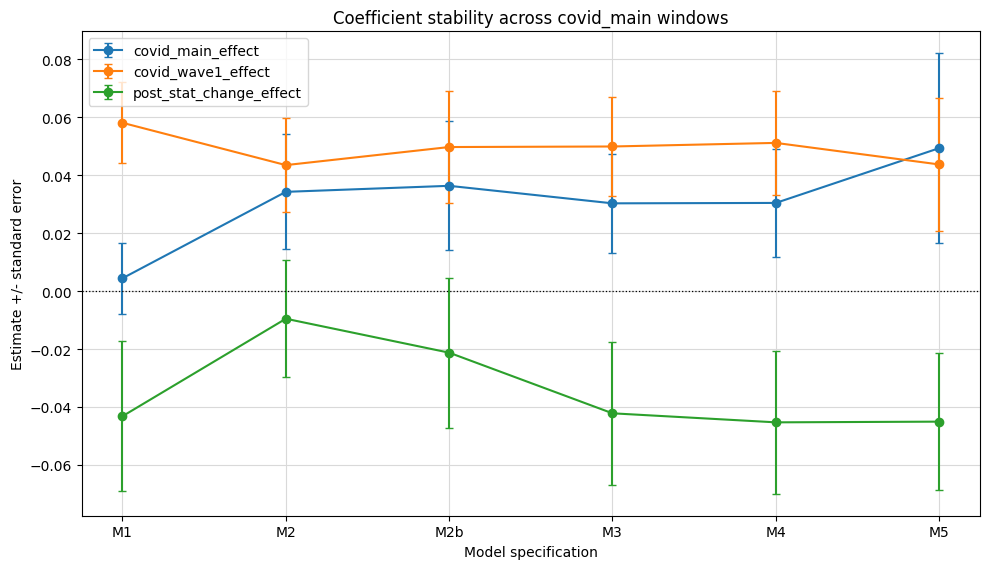

In [7]:
# 9. 係数比較図
# covid_main の終期を動かしたとき、主要係数がどの程度動くかを見る。

key_params = ["covid_main_effect", "covid_wave1_effect", "post_stat_change_effect"]
coef_focus = coefficients_df[coefficients_df["parameter"].isin(key_params)].copy()
coef_focus = coef_focus.merge(specs[["model_id", "note"]], on="model_id", how="left")

fig, ax = plt.subplots(figsize=(10, 5.8))
for parameter, group in coef_focus.groupby("parameter"):
    group = group.set_index("model_id").loc[specs["model_id"]].reset_index()
    ax.errorbar(
        group["model_id"],
        group["estimate"],
        yerr=group["std_error"],
        marker="o",
        capsize=3,
        linewidth=1.5,
        label=parameter,
    )

ax.axhline(0, color="black", linestyle=":", linewidth=0.9)
ax.set_title("Coefficient stability across covid_main windows")
ax.set_xlabel("Model specification")
ax.set_ylabel("Estimate +/- standard error")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend()
fig.tight_layout()
plt.show()

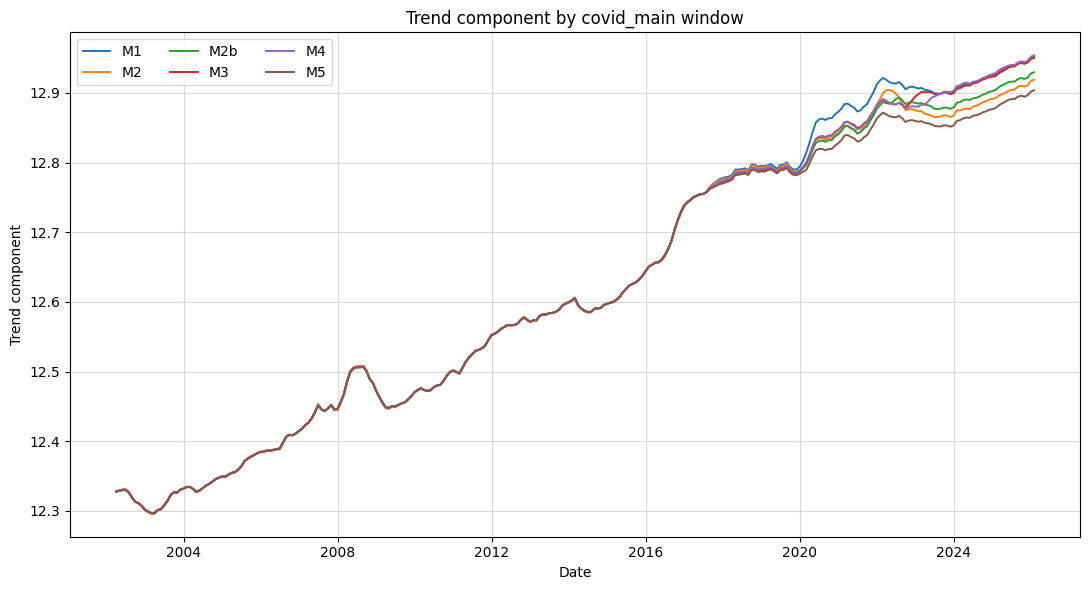

In [8]:
# 10. トレンド比較図
# イベントダミーの置き方が悪いと、トレンド側に不自然な屈曲が出ることがある。
# ここでは各仕様の trend component を同じ図で見比べる。

fig, ax = plt.subplots(figsize=(11, 6))
for model_id in specs["model_id"]:
    if model_id in trend_by_model:
        ax.plot(trend_by_model[model_id].index, trend_by_model[model_id], linewidth=1.4, label=model_id)

ax.set_title("Trend component by covid_main window")
ax.set_xlabel("Date")
ax.set_ylabel("Trend component")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

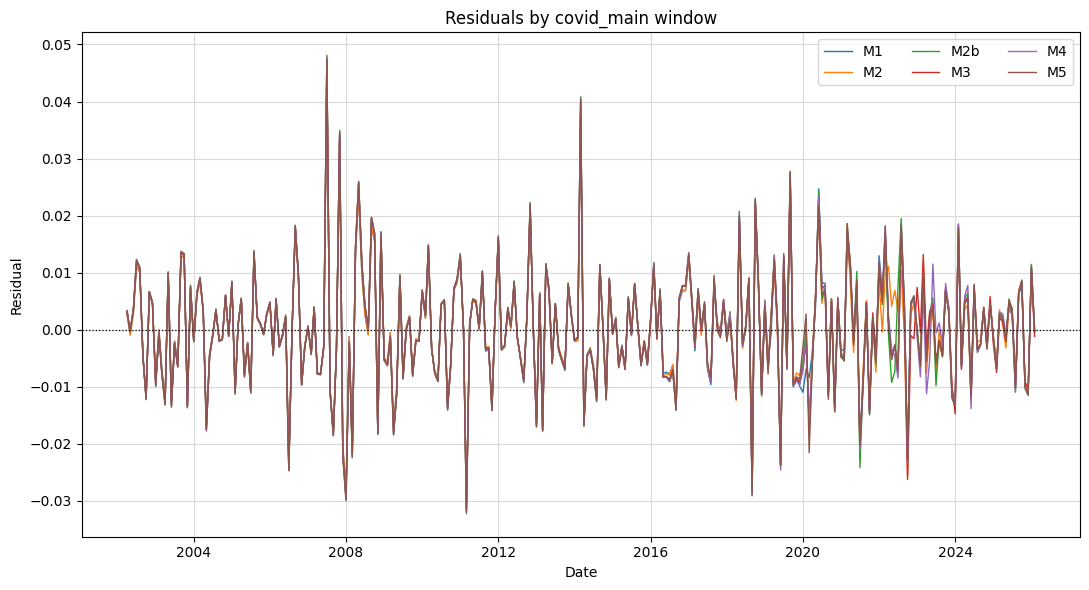

In [9]:
# 11. 残差比較図
# 仕様によって特定時期の残差が偏っていないか、また自己相関が残っていそうかを目視する。

fig, ax = plt.subplots(figsize=(11, 6))
for model_id in specs["model_id"]:
    if model_id in residual_by_model:
        ax.plot(residual_by_model[model_id].index, residual_by_model[model_id], linewidth=1.0, label=model_id)

ax.axhline(0, color="black", linestyle=":", linewidth=0.9)
ax.set_title("Residuals by covid_main window")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

In [10]:
# 12. output/sensitivity/ に結果を保存
# 論文用の output/tables や output/figures は触らず、探索分析専用の場所にだけ保存する。

comparison_df.to_csv(SENSITIVITY_DIR / "covid_main_window_comparison.csv", index=False)
coefficients_df.to_csv(SENSITIVITY_DIR / "covid_main_window_coefficients.csv", index=False)
diagnostics_df.to_csv(SENSITIVITY_DIR / "covid_main_window_diagnostics.csv", index=False)

successful = comparison_df[comparison_df["status"] == "success"].copy()
successful = successful.set_index("model_id").loc[specs["model_id"]].reset_index()

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9.5, 8.5), sharex=True)
for ax, metric, label in zip(axes, ["log_likelihood", "aic", "bic"], ["Log likelihood", "AIC", "BIC"]):
    ax.plot(successful["model_id"], successful[metric], marker="o", color="black")
    ax.set_ylabel(label)
    ax.grid(True, color="0.85", linewidth=0.8)
axes[-1].set_xlabel("Model specification")
fig.suptitle("Fit metrics by covid_main window", y=0.995)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "covid_main_window_fit_metrics.png", dpi=300, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5.8))
for parameter, group in coef_focus.groupby("parameter"):
    group = group.set_index("model_id").loc[specs["model_id"]].reset_index()
    ax.errorbar(group["model_id"], group["estimate"], yerr=group["std_error"], marker="o", capsize=3, linewidth=1.5, label=parameter)
ax.axhline(0, color="black", linestyle=":", linewidth=0.9)
ax.set_title("Coefficient stability across covid_main windows")
ax.set_xlabel("Model specification")
ax.set_ylabel("Estimate +/- standard error")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend()
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "covid_main_window_coefficients.png", dpi=300, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 6))
for model_id in specs["model_id"]:
    if model_id in trend_by_model:
        ax.plot(trend_by_model[model_id].index, trend_by_model[model_id], linewidth=1.4, label=model_id)
ax.set_title("Trend component by covid_main window")
ax.set_xlabel("Date")
ax.set_ylabel("Trend component")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "covid_main_window_trends.png", dpi=300, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 6))
for model_id in specs["model_id"]:
    if model_id in residual_by_model:
        ax.plot(residual_by_model[model_id].index, residual_by_model[model_id], linewidth=1.0, label=model_id)
ax.axhline(0, color="black", linestyle=":", linewidth=0.9)
ax.set_title("Residuals by covid_main window")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.grid(True, color="0.85", linewidth=0.8)
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(SENSITIVITY_DIR / "covid_main_window_residuals.png", dpi=300, bbox_inches="tight")
plt.close(fig)

print("Saved files to", SENSITIVITY_DIR)

Saved files to C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\sensitivity


## 13. 結果の読み取り

今回の実行結果では、AIC/BIC ともに **M5（2020-03-01 以降ずっと）** が最も低く、統計的な当てはまりだけを見ると M5 が有利だった。対数尤度も M5 が最も高い。

`covid_main` 係数はすべての仕様で正だった。大きさはおおむね 0.004 から 0.049 の範囲で、M1 ではほぼゼロに近く、終了時点を後ろに伸ばすと大きくなる傾向がある。ただし、有意性は安定していない。M2 や M3 では 10% 水準付近まで近づくが、M5 では係数は大きい一方で標準誤差も大きく、p値は十分小さくない。

`covid_wave1` 係数は一貫して正で、0.04 から 0.06 程度に収まっている。多くの仕様で有意、または少なくとも 10% 水準に近く、第一波の短期的な需要増という解釈は比較的安定している。

`post_stat_change` 係数は多くの仕様で負になった。M1, M3, M4, M5 では 10% 水準付近まで近づく一方、M2 や M2b では有意とは言いにくい。これは、`covid_main` の終了時点と後続統計接続補正が、2022年以降の水準変化をどちらで受け持つかに影響している可能性を示している。

収束については、`converged`, `warnflag`, `convergence_warning` を比較表に記録した。収束警告が出た仕様は、AIC/BIC が良く見えても係数解釈を慎重に扱う必要がある。

M5 は当てはまりが良いが、`covid_main` を 2020年3月以降ずっと 1 にするため、パンデミック影響を恒久的な水準変化として解釈してしまうリスクがある。実務的・社会的な説明としては、感染症影響、EC定着、統計接続、その他の構造変化が混ざったものを単一の `covid_main` に背負わせている可能性がある。

## 14. 暫定結論

この感度分析から、`covid_main` の終了時点は係数解釈と `post_stat_change` の推定に影響することが分かった。

したがって、AIC/BIC だけで仕様を決めない。統計的当てはまり、係数安定性、トレンド形状、残差診断、外部妥当性を合わせて判断する必要がある。

現段階では、主分析採用候補を1つに固定しない。M5 は当てはまりの点では強い候補だが、恒久的な水準変化としての解釈リスクがある。M2-M4 のように社会的な区切りを持つ仕様も含めて、ゼミで相談してから論文用の正規パイプラインへ切り出す。